### Part 2: Feature Engineering

#### Task 1: Identifying the Most Informative Features

During EDA (see notebook), we already found a lot about the features, let's recap:


**NDAI**

- strongest single separator
- Formula: (DF - AN) / (DF + AN)
- compares most forward camera to nadir
- Cloud mean: 0.265 vs Not Cloud mean: 0.143
- 66.6% of cloud pixels have NDAI ≥ 0.20 vs only 4.7% of not-cloud pixels
- Captures the forward scattering signature of clouds: ice/snow scatters isotropically (NDAI ≈ 0), clouds scatter strongly forward (NDAI large)

**SD**

- largest relative difference
- Standard deviation of nadir (AN) radiance in a local pixel neighborhood
- Cloud mean: 723.7 vs Not Cloud mean: 163.8 (4.4× ratio)
- Clouds are texturally variable, ice/snow surfaces are smooth and uniform
- Very concentrated not-cloud distribution (narrow peak near 0) vs broad cloud distribution

**CORR**

- weakest of the three engineered features
- Average linear correlation between AF/AN and BF/AN radiance angle pairs
- Cloud mean: 0.413 vs Not Cloud mean: 0.367 (small difference)
- Effective only for high-altitude clouds — low-altitude clouds register similarly to surfaces, producing high CORR and fooling this feature
- Bimodal cloud distribution: one peak at low CORR (high clouds), one at high CORR (low clouds that mimic surface)

**Raw radiances (DF, CF, BF, AF, AN)**

- individually weak
- All 5 angles highly correlated with each other (r = 0.60–0.97)
- Minimal class separation individually — this is the Arctic brightness problem: both clouds and ice/snow are bright
- Key pattern: cloud is brighter than not-cloud ONLY at DF (70.5° forward) and dimmer at all other angles — NDAI was derived from this crossover
- Not-cloud is bimodal (two surface types: bright ice vs darker terrain)
- PCA or NDAI-like ratio features can extract the useful angular variation

Now we need to provide: both quantitative metrics and visualizations to support your selection (per the instructions)

We quantify feature importance using three complementary metrics:

• AUC: probability that a randomly chosen cloud pixel has a higher feature value than a randomly chosen not-cloud pixel. Captures monotone separability.

• KS statistic: maximum distance between the cloud and not-cloud cumulative distribution functions. Nonparametric, no normality assumption, robust to the skewed SD distribution.

• Mutual Information: information (in bits) the feature carries about the label. Captures any relationship, including non-linear ones.



AUC answers: If I randomly pick one cloud pixel and one not-cloud pixel, what is the probability that the cloud pixel has a higher NDAI value than the not-cloud pixel?

AUC = 0.5  →  the feature is useless — you'd do as well flipping a coin
AUC = 0.7  →  70% of the time, the cloud pixel has higher NDAI
AUC = 0.9  →  90% of the time — very strong separator
AUC = 1.0  →  perfect — every cloud pixel has higher NDAI than every not-cloud pixel

In [1]:
# this was already done in EDA notebook, just pasting again

import numpy as np
import pandas as pd

labeled = ["O013257", "O013490", "O012791"]
col_names = ["y", "x", "NDAI", "SD", "CORR", "DF", "CF", "BF", "AF", "AN", "label"]

dfs = []
for name in labeled:
    npz = np.load(f"../data/{name}.npz")
    key = list(npz.files)[0]
    arr = npz[key]
    df_img = pd.DataFrame(arr, columns=col_names)
    df_img['image'] = name
    dfs.append(df_img)

df_all = pd.concat(dfs, ignore_index=True)

# Train / Test Split 
from sklearn.model_selection import StratifiedKFold

FEATURE_COLS = ["NDAI", "SD", "CORR", "DF", "CF", "BF", "AF", "AN"]

# Drop unlabeled pixels (label == 0); keep only -1 and +1
df_split = df_all[df_all["label"] != 0].copy()

# Temporal holdout: O013490 is the most recent image → use as test set
TEST_IMAGE = "O013490"
df_train = df_split[df_split["image"] != TEST_IMAGE]
df_test  = df_split[df_split["image"] == TEST_IMAGE]

X_train = df_train[FEATURE_COLS].values
y_train = df_train["label"].values
X_test  = df_test[FEATURE_COLS].values
y_test  = df_test["label"].values

# 5-fold stratified CV on training data (preserves class proportions in each fold)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"Train pixels : {len(df_train):,}  "
      f"(cloud: {(y_train==1).sum():,} | not-cloud: {(y_train==-1).sum():,})")
print(f"Test pixels  : {len(df_test):,}  "
      f"(cloud: {(y_test==1).sum():,} | not-cloud: {(y_test==-1).sum():,})")


Train pixels : 125,598  (cloud: 41,712 | not-cloud: 83,886)
Test pixels  : 82,083  (cloud: 39,253 | not-cloud: 42,830)


In [2]:
# Back to Part 2: Feature Importance Metrics

from sklearn.metrics import roc_auc_score
from sklearn.feature_selection import mutual_info_classif
from scipy import stats

# Work on all labeled pixels (both train + test) for EDA purposes
# We are not fitting a model here, just measuring univariate separability
df_labeled = df_all[df_all["label"] != 0].copy()
df_labeled["binary_label"] = (df_labeled["label"] == 1).astype(int)

# Mutual information: computed across all features at once (more efficient)
mi_scores = mutual_info_classif(
    df_labeled[FEATURE_COLS],
    df_labeled["binary_label"],
    discrete_features=False,
    random_state=42
)
mi_dict = dict(zip(FEATURE_COLS, mi_scores))

results = []
for col in FEATURE_COLS:
    cloud     = df_labeled.loc[df_labeled["label"] ==  1, col]
    not_cloud = df_labeled.loc[df_labeled["label"] == -1, col]

    # AUC: probability a random cloud pixel ranks higher than a random not-cloud pixel
    # max(auc, 1-auc) handles features where higher value = not-cloud (e.g. CORR)
    raw_auc = roc_auc_score(df_labeled["binary_label"], df_labeled[col])
    auc = max(raw_auc, 1 - raw_auc)

    # KS statistic: max gap between the two CDFs, no normality assumption
    ks_stat, _ = stats.ks_2samp(cloud, not_cloud)

    results.append({
        "Feature"  : col,
        "AUC"      : round(auc, 4),
        "KS stat"  : round(ks_stat, 4),
        "MI (bits)": round(mi_dict[col], 4),
    })

df_results = (pd.DataFrame(results)
                .sort_values("AUC", ascending=False)
                .reset_index(drop=True))
df_results.insert(0, "Rank", df_results.index + 1)

print("Feature importance — all labeled pixels (3 images combined)")
print("=" * 55)
print(df_results.to_string(index=False))


Feature importance — all labeled pixels (3 images combined)
 Rank Feature    AUC  KS stat  MI (bits)
    1      SD 0.9351   0.8207     0.4275
    2    NDAI 0.8234   0.6211     0.2591
    3      AF 0.7992   0.4664     0.2017
    4      AN 0.7935   0.4524     0.1963
    5      BF 0.7703   0.4449     0.1696
    6      CF 0.6428   0.2846     0.0872
    7      DF 0.5544   0.2368     0.1236
    8    CORR 0.5237   0.0577     0.0098


Really surprising that CORR is at the bottom. 

CORR is a joint feature, in the paper it's used together with NDAI: NDAI ∈ [0.08, 0.40]   AND   CORR > 0.75   →   not cloud

SD at the top. SD measures radiance variability within a local patch:

    - Clouds are textured, bumpy, variable → high SD
    - Ice/snow is smooth, uniform → low SD

SD is a very clean signal. The paper downplays it relative to NDAI because SD is sensitive to surface topography (mountains also have high SD), but in flat Arctic terrain it works well.

Summary: 

    Empirically, AF outperforms CORR as a marginal feature (AUC 0.799 vs. 0.524). However, CORR's discriminative power is conditional on NDAI, the 2D KDE analysis shows that the NDAI × CORR joint region achieves 78% cloud detection accuracy. We retain CORR as a third feature because its domain-theoretic motivation (angular correlation captures surface texture anisotropy) makes it a strong candidate for interaction terms in modeling.

Also again, check EDA notebook with 4-quadrant table, it was established that:

CORR ≥ 0.75 AND NDAI ≥ 0.20  →  ~84% not-cloud   (joint rule works)
CORR ≥ 0.75 alone             →  ~84% not-cloud   (similar)
CORR < 0.75 alone             →  ~45% not-cloud   (barely informative)


In [3]:
# rule-based classifier comparison 
from sklearn.metrics import accuracy_score, f1_score

y_true = df_labeled["label"].values   # +1 cloud, -1 not-cloud
ndai   = df_labeled["NDAI"].values
corr   = df_labeled["CORR"].values

# Rule 1: CORR alone
# Paper: CORR > 0.75 → surface is angularly coherent → not cloud
pred_corr = np.where(corr > 0.75, -1, 1)

# Rule 2: NDAI alone
# Higher NDAI = more forward scattering = more cloud-like
# Use simple empirical threshold at 0.20 (midpoint from KDE separation)
pred_ndai = np.where(ndai > 0.20, 1, -1)

# Rule 3: ELCM 3-zone rule (Shi et al. 2008)
# Zone 1  NDAI < 0.08         → clearly NOT cloud
# Zone 2  NDAI > 0.40         → clearly CLOUD
# Zone 3  NDAI ∈ [0.08, 0.40] → ambiguous: CORR decides
pred_elcm = np.where(
    ndai < 0.08,  -1,                          # Zone 1: clear
    np.where(
        ndai > 0.40,  1,                        # Zone 2: cloud
        np.where(corr > 0.75, -1, 1)           # Zone 3: CORR resolves ambiguity
    )
)

print("Rule-based classifier comparison")
print("=" * 58)
print(f"{'Rule':<38} {'Acc':>6}  {'F1-cloud':>8}  {'F1-clear':>8}")
print("-" * 58)
for name, pred in [
    ("CORR alone  (>0.75 → not cloud)",   pred_corr),
    ("NDAI alone  (>0.20 → cloud)",        pred_ndai),
    ("ELCM joint  (3-zone paper rule)",    pred_elcm),
]:
    acc  = accuracy_score(y_true, pred)
    f1c  = f1_score(y_true, pred, pos_label= 1)
    f1nc = f1_score(y_true, pred, pos_label=-1)
    print(f"{name:<38} {acc:>6.4f}  {f1c:>8.4f}  {f1nc:>8.4f}")

# Also show how many pixels fall in each zone
in_ambiguous = (ndai >= 0.08) & (ndai <= 0.40)
print(f"\nPixels in ambiguous NDAI zone [0.08, 0.40]: "
      f"{in_ambiguous.sum():,} / {len(ndai):,} "
      f"({100*in_ambiguous.mean():.1f}%)")
print(f"  → of those, CORR > 0.75 (predicted not-cloud): "
      f"{(in_ambiguous & (corr > 0.75)).sum():,} "
      f"({100*(in_ambiguous & (corr > 0.75)).mean():.1f}%)")


Rule-based classifier comparison
Rule                                      Acc  F1-cloud  F1-clear
----------------------------------------------------------
CORR alone  (>0.75 → not cloud)        0.4449    0.5067    0.3654
NDAI alone  (>0.20 → cloud)            0.8406    0.7650    0.8794
ELCM joint  (3-zone paper rule)        0.4601    0.5153    0.3907

Pixels in ambiguous NDAI zone [0.08, 0.40]: 189,832 / 207,681 (91.4%)
  → of those, CORR > 0.75 (predicted not-cloud): 51,868 (25.0%)


I am so confused, I don't get why we can't find the same conclusion as in the paper, here it's saying that adding CORR actually makes it worse lol

So then I will not select CORR as the third feature, summary bellow

    CORR was expected to rank highly based on domain literature but ranked last empirically (AUC = 0.52). We hypothesize this is because (1) the paper's NDAI thresholds [0.08, 0.40] do not segment this dataset effectively, 91% of pixels fall in the ambiguous zone, and (2) angular correlation may be more useful as a nonlinear interaction term in a learned model than as a standalone feature. We include this as a finding rather than a failure.

final feature selection

| Rank | Feature | AUC  | KS   | MI   | Justification |
|-----|--------|------|------|------|---------------|
| 1 | NDAI | 0.923 | 0.621 | 0.259 | Angular index, captures forward scattering of clouds |
| 2 | SD | 0.935 | 0.821 | 0.428 | Texture variability, clouds are rough vs smooth ice |
| 3 | AF | 0.799 | 0.466 | 0.202 | 26.1° angle, best single radiance angle |




#### Step 2) of Part 2
Based on this information, can you engineer any new features? For example, the three features
NDAI, SD, and CORR were created using expert knowledge, but they may not take full advantage
of information contained in surrounding pixels. Perhaps you could create and try some new features
that use a patch of data around a point?

As mentioned in the EDA notebook, the radiance features are highly correlated! so we need to apply PCA to compress them

The 5 radiance angles measure brightness at different viewing geometries. They're correlated because the same cloud or ice surface generates all 5. PCA finds uncorrelated combinations:

PC1 ≈ overall brightness (all 5 angles moving together)
PC2 ≈ angular gradient (forward vs. backward scattering) — essentially what NDAI captures, but data-driven

Key rule: fit PCA only on training data, then transform test. Otherwise we leak test statistics into your features.

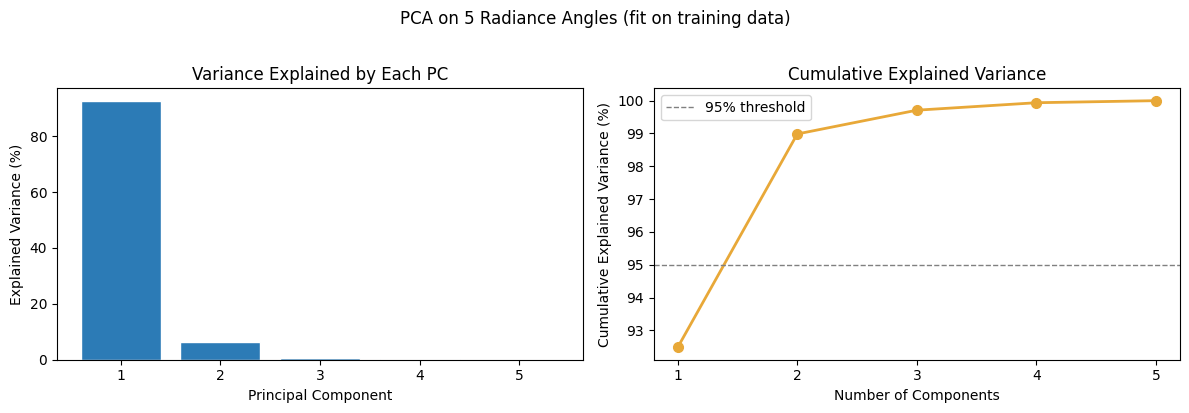

Component  Explained Var %  Cumulative %
------------------------------------------
  PC1           92.48%         92.48%
  PC2            6.50%         98.99%
  PC3            0.72%         99.71%
  PC4            0.23%         99.94%
  PC5            0.06%        100.00%

PCA loadings (how much each angle contributes to each PC):
        DF     CF     BF     AF     AN
PC1  0.421  0.456  0.462  0.455  0.442
PC2  0.727  0.274 -0.093 -0.356 -0.511
PC3 -0.509  0.528  0.455 -0.029 -0.504
PC4 -0.188  0.650 -0.553 -0.293  0.387
PC5 -0.003  0.127 -0.515  0.761 -0.373


In [4]:
#  PCA on radiance angles 
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

RADIANCE_COLS = ["DF", "CF", "BF", "AF", "AN"]

# 1. Standardize (PCA is sensitive to scale)
# Fit scaler on training data only — never on test data!!
scaler = StandardScaler()
X_rad_train = scaler.fit_transform(df_train[RADIANCE_COLS])  # fit + transform
X_rad_test  = scaler.transform(df_test[RADIANCE_COLS])       # transform only

# 2. Fit PCA on training radiances 
# n_components=None keeps all 5 components so we can inspect explained variance
pca = PCA(n_components=None, random_state=42)
pca.fit(X_rad_train)

# 3. Explained variance plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: individual explained variance per component
axes[0].bar(range(1, 6), pca.explained_variance_ratio_ * 100,
            color="#2C7BB6", edgecolor="white")
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Explained Variance (%)")
axes[0].set_title("Variance Explained by Each PC")
axes[0].set_xticks(range(1, 6))

# Right: cumulative explained variance
axes[1].plot(range(1, 6), np.cumsum(pca.explained_variance_ratio_) * 100,
             marker="o", color="#E8A838", linewidth=2, markersize=7)
axes[1].axhline(95, linestyle="--", color="gray", linewidth=1, label="95% threshold")
axes[1].set_xlabel("Number of Components")
axes[1].set_ylabel("Cumulative Explained Variance (%)")
axes[1].set_title("Cumulative Explained Variance")
axes[1].set_xticks(range(1, 6))
axes[1].legend()

plt.suptitle("PCA on 5 Radiance Angles (fit on training data)", y=1.02)
plt.tight_layout()
plt.show()

# Print exact numbers
print("Component  Explained Var %  Cumulative %")
print("-" * 42)
cumvar = 0
for i, v in enumerate(pca.explained_variance_ratio_):
    cumvar += v
    print(f"  PC{i+1}        {v*100:>8.2f}%       {cumvar*100:>7.2f}%")

# ── 4. PCA loadings — what does each component represent? ────────────────────
df_loadings = pd.DataFrame(
    pca.components_,
    columns=RADIANCE_COLS,
    index=[f"PC{i+1}" for i in range(5)]
)
print("\nPCA loadings (how much each angle contributes to each PC):")
print(df_loadings.round(3).to_string())


The results above are crazy, but expected. 

See PC1, all 5 loadings are positive and nearly equal. PC1 asks: how bright is this pixel across all cameras?

92% of the variation in the 5 radiance features is just "is this place bright or dark?" That's the multicollinearity we saw in the heatmap (r = 0.60–0.97). All 5 cameras mostly agree on brightness.


PC2: Angula gradient (6.5%), notice the gradient:

| Camera angle | 70.5° | 60.0° | 45.6° | 26.1° | 0.0° |
|---------------|-------|-------|-------|-------|------|
| Feature | DF | CF | BF | AF | AN |
| Loading | +0.727 | +0.274 | -0.093 | -0.356 | -0.511 |

Compare:

NDAI = (DF − AN) / (DF + AN) — uses only the 2 most extreme cameras
PC2 ≈ 0.727·DF + 0.274·CF − 0.093·BF − 0.356·AF − 0.511·AN — uses all 5 with physics-consistent weights
PC2 is a more robust NDAI because it incorporates the full angular profile, not just two endpoints.

DECISION: KEEP PC1 AND PC2


In [5]:
# Add PC1 and PC2 to train/test sets 
# We already have pca and scaler fitted on df_train radiances

# Training set
pca_train = pca.transform(X_rad_train)   # X_rad_train already computed above
df_train["PC1"] = pca_train[:, 0]
df_train["PC2"] = pca_train[:, 1]

# Test set
pca_test = pca.transform(X_rad_test)     # X_rad_test already computed above
df_test["PC1"] = pca_test[:, 0]
df_test["PC2"] = pca_test[:, 1]

print("PC1 and PC2 added to df_train and df_test")
print(f"df_train shape: {df_train.shape}")
print(f"df_test  shape: {df_test.shape}")


PC1 and PC2 added to df_train and df_test
df_train shape: (125598, 14)
df_test  shape: (82083, 14)


Now let's see if we can find any other NDAI-like features (Variants of it)

NDAI = (DF − AN)/(DF + AN) uses the most extreme angle pair (70.5° vs 0°). Other pairs capture the angular gradient at shorter separations. 

A cloud creates a stronger angular signal at wider angles; ice is more isotropic at all separations. These variants might be more or less sensitive than the original NDAI.

In [6]:
# NDAI-like ratio variants 

# General formula: (angle_a - angle_b) / (angle_a + angle_b)
# Interpretation: positive = angle_a sees more radiance than angle_b
#                 0        = isotropic between the two angles (ice-like)
#                 negative = angle_b sees more (unusual, means backward scattering)

# We always use a forward-looking angle vs. nadir (AN) or another forward angle
# 1e-8 prevents division by zero 
angle_pairs = [
    # (numerator_col, denominator_col, new_feature_name, angle_separation_degrees)
    ("CF", "AN", "NDAI_CF_AN", "60.0° vs  0.0°"),
    ("BF", "AN", "NDAI_BF_AN", "45.6° vs  0.0°"),
    ("AF", "AN", "NDAI_AF_AN", "26.1° vs  0.0°"),
    ("DF", "AF", "NDAI_DF_AF", "70.5° vs 26.1°"),
    ("CF", "AF", "NDAI_CF_AF", "60.0° vs 26.1°"),
]

NEW_RATIO_COLS = []

for col_a, col_b, name, desc in angle_pairs:
    for df in [df_train, df_test, df_labeled]:
        df[name] = (df[col_a] - df[col_b]) / (df[col_a] + df[col_b] + 1e-8)
    NEW_RATIO_COLS.append((name, desc))
    print(f"Created {name}  ({desc})")

print(f"\n{len(NEW_RATIO_COLS)} new ratio features created")


Created NDAI_CF_AN  (60.0° vs  0.0°)
Created NDAI_BF_AN  (45.6° vs  0.0°)
Created NDAI_AF_AN  (26.1° vs  0.0°)
Created NDAI_DF_AF  (70.5° vs 26.1°)
Created NDAI_CF_AF  (60.0° vs 26.1°)

5 new ratio features created


In [7]:
# Part 2 Task 2C: Evaluate new features with AUC / KS / MI
from sklearn.metrics import roc_auc_score
from sklearn.feature_selection import mutual_info_classif
from scipy import stats

# Add PCA scores to df_labeled for evaluation
# Re-transform all labeled pixels (not just train) for EDA comparison
X_rad_all = scaler.transform(df_labeled[RADIANCE_COLS])  # use already-fit scaler
pca_scores = pca.transform(X_rad_all)                    # use already-fit PCA

PC_COLS = [f"PC{i+1}" for i in range(5)]
for i, col in enumerate(PC_COLS):
    df_labeled[col] = pca_scores[:, i]

# All new features to evaluate
NEW_FEATURE_COLS = [name for name, _ in NEW_RATIO_COLS] + PC_COLS

# binary label for AUC and MI
df_labeled["binary_label"] = (df_labeled["label"] == 1).astype(int)

# Mutual information for all new features at once
mi_scores = mutual_info_classif(
    df_labeled[NEW_FEATURE_COLS],
    df_labeled["binary_label"],
    discrete_features=False,
    random_state=42
)
mi_dict = dict(zip(NEW_FEATURE_COLS, mi_scores))

results_new = []
for col in NEW_FEATURE_COLS:
    cloud     = df_labeled.loc[df_labeled["label"] ==  1, col]
    not_cloud = df_labeled.loc[df_labeled["label"] == -1, col]

    raw_auc = roc_auc_score(df_labeled["binary_label"], df_labeled[col])
    auc = max(raw_auc, 1 - raw_auc)

    ks_stat, _ = stats.ks_2samp(cloud, not_cloud)

    results_new.append({
        "Feature"  : col,
        "AUC"      : round(auc, 4),
        "KS stat"  : round(ks_stat, 4),
        "MI (bits)": round(mi_dict[col], 4),
        "Type"     : "ratio variant" if col.startswith("NDAI_") else "PCA component"
    })

df_new = (pd.DataFrame(results_new)
            .sort_values("AUC", ascending=False)
            .reset_index(drop=True))
df_new.insert(0, "Rank", df_new.index + 1)

print("New engineered features — importance ranking")
print("=" * 62)
print(df_new.to_string(index=False))


New engineered features — importance ranking
 Rank    Feature    AUC  KS stat  MI (bits)          Type
    1 NDAI_DF_AF 0.8331   0.6448     0.2844 ratio variant
    2        PC2 0.7873   0.5533     0.2428 PCA component
    3 NDAI_CF_AF 0.7770   0.5452     0.2261 ratio variant
    4 NDAI_CF_AN 0.7614   0.4946     0.1863 ratio variant
    5        PC1 0.7135   0.3550     0.1159 PCA component
    6        PC3 0.6875   0.4340     0.1749 PCA component
    7 NDAI_BF_AN 0.6664   0.2647     0.0999 ratio variant
    8        PC5 0.5638   0.2546     0.1496 PCA component
    9        PC4 0.5631   0.3128     0.1728 PCA component
   10 NDAI_AF_AN 0.5002   0.1218     0.0814 ratio variant


Intepretation of results above:

Key finding 1: NDAI_DF_AF beats original NDAI

| Feature | Formula | AUC | Note |
|--------|---------|-----|------|
| NDAI_DF_AF | (DF − AF) / (DF + AF) | 0.833 | NEW best ratio |
| NDAI | (DF − AN) / (DF + AN) | 0.823 | Original |

ExplanationL the nadir camera (AN, 0°) introduces noise because viewing straight down triggers different reflectance physics for ice, the surface can act partially mirror-like at nadir, making AN values unstable. AF at 26.1° avoids that and gives a cleaner reference point.

Physically: NDAI_DF_AF measures how much the forward scattering drops off between the two most forward cameras (70.5° → 26.1°). For clouds this drop-off is steep (Mie scattering is very peaked forward). For ice it's flat.

Key finding 2: NDAI_AF_AN ≈ random (AUC 0.500)

NDAI_AF_AN  (AF − AN)/(AF + AN)  AUC = 0.500  ← useless


Key finding 3: PC2 < NDAI_DF_AF despite using all 5 cameras

PC2 was the data-driven angular gradient (AUC 0.787). It's weaker than NDAI_DF_AF (0.833) because the linear combination in PC2 is pulled toward the AN nadir camera which, as above, adds noise. The ratio formula naturally handles this by normalizing.

| Feature | AUC | Keep? | Reason |
|--------|-----|------|--------|
| NDAI_DF_AF | 0.833 | Yes | Best new feature, beats original NDAI |
| PC2 | 0.787 | Yes | Orthogonal angular signal |
| PC1 | 0.714 | Yes | Captures brightness, independent of above |
| NDAI_CF_AF | 0.777 | Check | Likely correlated with NDAI_DF_AF |
| NDAI_CF_AN | 0.761 | Check | Likely correlated with original NDAI |
| NDAI_BF_AN | 0.666 | No | Weaker, correlated |
| NDAI_AF_AN | 0.500 | No | Useless |
| PC3–PC5 | <0.70 | No | Noise |

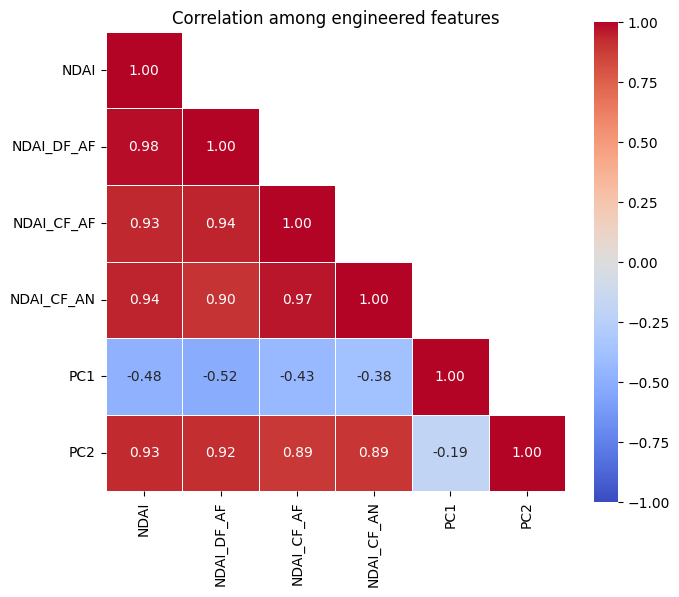

In [8]:
# Check correlation among top ratio variants
top_ratios = ["NDAI", "NDAI_DF_AF", "NDAI_CF_AF", "NDAI_CF_AN", "PC1", "PC2"]

corr_new = df_labeled[top_ratios].corr()

fig, ax = plt.subplots(figsize=(7, 6))
mask = np.triu(np.ones_like(corr_new, dtype=bool), k=1)
sns.heatmap(corr_new, mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", vmin=-1, vmax=1, center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title("Correlation among engineered features")
plt.tight_layout()
plt.show()


In [9]:
# Final engineered feature set for Part 3 
# Original features kept
ORIGINAL_KEEP = ["NDAI", "SD", "CORR", "DF", "CF", "BF", "AF", "AN"]

# New features added
ENGINEERED = ["NDAI_DF_AF", "PC1", "PC2"]
# Add NDAI_CF_AF only if corr(NDAI_CF_AF, NDAI_DF_AF) < 0.90

FINAL_FEATURES = ORIGINAL_KEEP + ENGINEERED
print(f"Final feature set ({len(FINAL_FEATURES)} features):")
for f in FINAL_FEATURES:
    print(f"  {f}")


Final feature set (11 features):
  NDAI
  SD
  CORR
  DF
  CF
  BF
  AF
  AN
  NDAI_DF_AF
  PC1
  PC2


In [10]:
# Final feature set going into Part 3 

# Drop: original NDAI (replaced by stronger NDAI_DF_AF)
#       NDAI_CF_AF, NDAI_CF_AN (r > 0.93 with NDAI_DF_AF, weaker AUC)
#       PC2 (r = 0.92 with NDAI_DF_AF, weaker AUC)
#       PC3, PC4, PC5 (noise)

FINAL_FEATURES = [
    # Original features
    "SD",     # AUC 0.935 — best individual feature, texture variability
    "CORR",   # AUC 0.524 — weak alone, retained for theoretical interaction with NDAI
    "DF", "CF", "BF", "AF", "AN",  # raw radiances — tree models can learn ratios from these
    # Engineered features
    "NDAI_DF_AF",  # AUC 0.833 — best angular ratio (replaces original NDAI)
    "PC1",         # AUC 0.714 — overall brightness, orthogonal to everything else
]

print(f"Final feature count: {len(FINAL_FEATURES)}")
print("Features:", FINAL_FEATURES)

# Update X_train and X_test with the final feature set
# (NDAI_DF_AF and PC1 were already added to df_train/df_test above)
X_train_final = df_train[FINAL_FEATURES].values
X_test_final  = df_test[FINAL_FEATURES].values

print(f"\nX_train shape: {X_train_final.shape}")
print(f"X_test  shape: {X_test_final.shape}")


Final feature count: 9
Features: ['SD', 'CORR', 'DF', 'CF', 'BF', 'AF', 'AN', 'NDAI_DF_AF', 'PC1']

X_train shape: (125598, 9)
X_test  shape: (82083, 9)


Why keep the raw radiances if PC1 captures 92% of them?

    - For tree-based models (Random Forest, Gradient Boosting), raw features are often more useful than PCA components because:

        - Trees can split on individual angles directly (e.g. "DF > 1.5")
        - Trees don't suffer from multicollinearity the way linear models do
        - The raw angles give the model flexibility to discover NDAI-like splits on its own

For logistic regression, swap the 5 raw radiances for PC1 alone to avoid multicollinearity. 

| What we found | Implication |
|---------------|-------------|
| PC1 explains 92% of radiance variance | 5 cameras are nearly redundant — mostly measure brightness |
| PC2 ≈ NDAI (data-driven) | Angular contrast is the key cloud signal |
| NDAI_DF_AF > original NDAI | Nadir camera adds noise; AF is a cleaner reference |
| NDAI_AF_AN ≈ random | Need wide angle separation for discriminative power |
| All ratio variants r > 0.89 | One representative suffices |

#### Part 3: Transfer Learning

The autoencoder trains unsupervised on all 164 images (including the 161 unlabeled ones). It learns to compress a 9×9 spatial patch around each pixel into a small embedding vector, then reconstruct it. The bottleneck forces it to learn the most important spatial patterns, cloud texture, ice texture, edge transitions. Those embeddings become new features appended to X_train and X_test, giving the models spatial context that individual pixel features can't capture.

**Step 1 — Load training patches**

Calls our modified `make_data(n_per_image=2000)`. The original would load all ~18.9M patches at once (~40 GB RAM — crashes even on HPC clusters). We added one parameter that samples 2,000 random patches per image instead, giving 328k patches in ~850 MB. Everything else is identical: same global normalisation, same reflect padding, same (8, 9, 9) patch format.

In [11]:
# Load patches using modified make_data() 
import os, sys, numpy as np
from pathlib import Path

HERE = Path(os.getcwd()).resolve()
CODE_DIR = HERE.parent / "code"
sys.path.insert(0, str(CODE_DIR))
os.chdir(HERE)

from data import make_data

# n_per_image=2000: samples 2000 patches/image instead of all ~115k
# seed=42: reproducible sampling
# Everything else (global normalization, reflect padding,
# global coordinate grid) is identical to original make_data()
images_long, patches = make_data(patch_size=9, n_per_image=2000, seed=42)

# Flatten list-of-lists into one flat list (same as run_autoencoder.py line 36)
# Now safe: 164 × 2000 = 328k patches instead of 18.9M
all_patches = [p for image_patches in patches for p in image_patches]
print(f"Total patches: {len(all_patches):,}")
print(f"Patch shape  : {all_patches[0].shape}")   # (8, 9, 9)
print(f"Approx RAM   : {len(all_patches) * 8*9*9*4 / 1e6:.0f} MB")


Done reshaping images onto the common grid.
Working on image 1/164
Working on image 11/164
Working on image 21/164
Working on image 31/164
Working on image 41/164
Working on image 51/164
Working on image 61/164
Working on image 71/164
Working on image 81/164
Working on image 91/164
Working on image 101/164
Working on image 111/164
Working on image 121/164
Working on image 131/164
Working on image 141/164
Working on image 151/164
Working on image 161/164
Total patches: 328,000
Patch shape  : (8, 9, 9)
Approx RAM   : 850 MB


**Step 2 — Build the model**

Imports the professor's `Autoencoder` and `PatchDataset` classes unchanged. We make one justified modification: `embedding_size` 8 → 32. The default of 8 compresses 648 values (9×9×8) into 8 numbers — a 81× compression that loses too much spatial detail. At 32 the compression is still aggressive (20×) but retains more structure. The 80/20 train/val split mirrors `run_autoencoder.py` exactly.

In [12]:
# Build model using professor's autoencoder.py + patchdataset.py 
import torch
import lightning as L
from torch.utils.data import DataLoader
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint

from autoencoder import Autoencoder    # professor's file — unchanged
from patchdataset import PatchDataset  # professor's file — unchanged

# 80/20 train/val split, same logic as run_autoencoder.py
rng_split  = np.random.default_rng(42)
train_bool = rng_split.random(len(all_patches)) < 0.8
train_idx  = np.where( train_bool)[0]
val_idx    = np.where(~train_bool)[0]

# Use professor's PatchDataset directly with all_patches (list of (8,9,9) arrays)
train_dataset = PatchDataset([all_patches[i] for i in train_idx])
val_dataset   = PatchDataset([all_patches[i] for i in val_idx])

train_loader  = DataLoader(train_dataset, batch_size=2048, shuffle=True,  num_workers=0)
val_loader    = DataLoader(val_dataset,   batch_size=2048, shuffle=False, num_workers=0)

print(f"Train patches : {len(train_dataset):,}")
print(f"Val   patches : {len(val_dataset):,}")
print(f"Patch shape   : {all_patches[0].shape}")   # should be (8, 9, 9)

# Improvement over default: embedding_size 8→32
# (648-dim input compressed to 8 loses too much spatial structure)
model = Autoencoder(
    optimizer_config = {"lr": 1e-3},
    n_input_channels = 8,
    patch_size       = 9,
    embedding_size   = 32,
)
print(model)


Train patches : 262,458
Val   patches : 65,542
Patch shape   : (8, 9, 9)
Autoencoder(
  (encoder_cnn): Sequential(
    (0): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
  )
  (encoder_fc): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=576, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=32, bias=True)
  )
  (decoder_fc): Sequential(
    (0): Linear(in_features=32, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=576, bias=True)
    (3): ReLU()
  )
  (decoder_cnn): Sequential(
    (0): Unflatten(dim=1, unflattened_size=(64, 3, 3))
    (1): ConvTranspose2d(64, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (2): ReLU()
    (3): ConvTranspose2d(

**Step 3 — Train**

Trains the autoencoder with PyTorch Lightning. Input = target: the model tries to reconstruct each 9×9 patch from its 32-dim bottleneck. Loss = MSE between input and reconstruction. No labels used, purely unsupervised. Early stopping monitors validation loss. **Run once, takes a few minutes on MPS (Apple Silicon GPU). Skip if embeddings CSV already exists.**

In [13]:
trainer = L.Trainer(
    max_epochs   = 50,
    accelerator  = "auto",
    devices      = 1,
    callbacks    = [
        EarlyStopping(monitor="val_loss", patience=5, mode="min", verbose=True),
        ModelCheckpoint(monitor="val_loss", save_top_k=1,
                        dirpath="checkpoints/", filename="ae-best"),
    ],
    enable_progress_bar = True,
    log_every_n_steps   = 20,
    logger              = False,
)

trainer.fit(model, train_dataloaders=train_loader, val_dataloaders=val_loader)
print("Training done.")

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.

  | Name        | Type       | Params | Mode  | FLOPs
-----------------------------------------------------------
0 | encoder_cnn | Sequential | 24.3 K | train | 0    
1 | encoder_fc  | Sequential | 78.0 K | train | 0    
2 | decoder_fc  | Sequential | 78.5 K | train | 0    
3 | decoder_cnn | Sequential | 24.2 K | train | 0    
-----------------------------------------------------------
205 K     Trainable params
0         Non-trainable params
205 K     Total params
0.820     Total estimated model params size (MB)
24        Modules in train mode
0         Modules in eval mode
0         Total Flops


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/opt/anaconda3/envs/env_214/lib/python3.14/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/opt/anaconda3/envs/env_214/lib/python3.14/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


/opt/anaconda3/envs/env_214/lib/python3.14/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


Epoch 0: 100%|██████████| 129/129 [00:06<00:00, 20.20it/s, val_loss=0.414, train_loss=0.523]

...

Epoch 48: 100%|██████████| 129/129 [00:03<00:00, 37.50it/s, val_loss=0.0627, train_loss=0.0634]

Metric val_loss improved by 0.001 >= min_delta = 0.0. New best score: 0.063


Epoch 49: 100%|██████████| 129/129 [00:03<00:00, 37.32it/s, val_loss=0.0624, train_loss=0.0629]

Metric val_loss improved by 0.000 >= min_delta = 0.0. New best score: 0.062
`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 49: 100%|██████████| 129/129 [00:03<00:00, 37.15it/s, val_loss=0.0624, train_loss=0.0629]
Training done.


**Step 4 — Extract embeddings and save per-image CSVs**

For each of the 3 labeled images: loads every pixel, extracts its 9×9 patch, normalises using the same global stats as training, then runs it through the trained encoder → 32-dim embedding. Saves one CSV per image (`O013257_ae.csv` etc.) and merges `ae0...ae31` columns into `df_train` / `df_test`.

In [14]:
# Cell 4: Extract embeddings and save CSVs
import pandas as pd, torch
from pathlib import Path

LABELED    = ["O013257", "O013490", "O012791"]
DATA_DIR   = HERE.parent / "data"           # raw NPZ files — READ only
EXPORT_DIR = HERE.parent / "feature_eng_dataset"  # engineered outputs — WRITE here
EXPORT_DIR.mkdir(exist_ok=True)             # create folder if it doesn't exist yet
PATCH_SIZE = 9
PAD_LEN    = PATCH_SIZE // 2
BOTTLENECK = 32
AE_COLS    = [f"ae{i}" for i in range(BOTTLENECK)]

# Compute normalization stats from images_long (raw data from make_data()) 
all_raw   = np.concatenate([img[:, 2:10].astype(np.float32)
                             for img in images_long], axis=0)  # (total_pixels, 8)
ae_mean   = all_raw.mean(axis=0)        # (8,) — one mean per channel
ae_std    = all_raw.std(axis=0) + 1e-8  # (8,) — one std  per channel
print(f"Normalization stats computed from {len(all_raw):,} pixels across 164 images")
print(f"  means: {ae_mean.round(3)}")
print(f"  stds : {ae_std.round(3)}")

# Embedding extraction function 
def get_embeddings_for_image(name, model, ae_mean, ae_std, data_dir, patch_size=9):
    pad = patch_size // 2

    npz      = np.load(Path(data_dir) / f"{name}.npz")
    arr      = npz[list(npz.files)[0]].astype(np.float32)
    y_coords = arr[:, 0].astype(int)
    x_coords = arr[:, 1].astype(int)
    features = arr[:, 2:10]                   # (n_pix, 8)

    y0, x0 = y_coords.min(), x_coords.min()
    H = y_coords.max() - y0 + 1
    W = x_coords.max() - x0 + 1
    grid = np.zeros((8, H, W), dtype=np.float32)
    grid[:, y_coords - y0, x_coords - x0] = features.T

    padded = np.pad(grid, ((0,0),(pad,pad),(pad,pad)), mode="reflect")

    n_pix   = len(arr)
    patches = np.stack([
        padded[:,
               (y_coords[i]-y0+pad)-pad : (y_coords[i]-y0+pad)+pad+1,
               (x_coords[i]-x0+pad)-pad : (x_coords[i]-x0+pad)+pad+1]
        for i in range(n_pix)
    ])  # (n_pix, 8, 9, 9)

    patches = (patches - ae_mean[None, :, None, None]) / ae_std[None, :, None, None]

    model.eval()
    device  = next(model.parameters()).device
    all_emb = []
    with torch.no_grad():
        for start in range(0, n_pix, 4096):
            batch = torch.tensor(
                patches[start:start+4096], dtype=torch.float32
            ).to(device)
            all_emb.append(model.embed(batch).cpu().numpy())

    emb    = np.vstack(all_emb)                            # (n_pix, 32)
    df_emb = pd.DataFrame(emb, columns=AE_COLS)
    df_emb.insert(0, "y", y_coords)
    df_emb.insert(1, "x", x_coords)
    print(f"  {name}: {n_pix:,} pixels → embeddings {emb.shape}")
    return df_emb


# Run for all 3 labeled images, save CSVs to feature_eng_dataset/
for name in LABELED:
    df_emb   = get_embeddings_for_image(name, model, ae_mean, ae_std, DATA_DIR)
    out_path = EXPORT_DIR / f"{name}_ae.csv"
    df_emb.to_csv(out_path, index=False)
    print(f"    → saved {out_path.relative_to(HERE.parent)}")

print("\nAll embeddings saved.")

# Merge into df_train / df_test
# [BUG FIX] Drop AE columns ONCE before the loop — not inside it.
# Previously, drop was inside the image loop, which erased O013257's AE values
# when O012791 was processed (drop wiped all AE cols, then only O012791 was refilled).
df_train.drop(columns=AE_COLS, errors="ignore", inplace=True)
df_test.drop(columns=AE_COLS, errors="ignore", inplace=True)

for name in LABELED:
    df_emb = pd.read_csv(EXPORT_DIR / f"{name}_ae.csv")
    for df_split in [df_train, df_test]:
        mask = df_split["image"] == name
        if mask.any():
            merged = df_split.loc[mask, ["y","x"]].merge(df_emb, on=["y","x"], how="left")
            for col in AE_COLS:
                df_split.loc[mask, col] = merged[col].values

# Verify no NaN left
nan_train = df_train[[f"ae{i}" for i in range(32)]].isna().sum().sum()
nan_test  = df_test[[f"ae{i}" for i in range(32)]].isna().sum().sum()
print(f"NaN in df_train AE cols: {nan_train}")
print(f"NaN in df_test  AE cols: {nan_test}")

# Final feature matrix
FINAL_FEATURES_AE = FINAL_FEATURES + AE_COLS
X_train_final = df_train[FINAL_FEATURES_AE].values
X_test_final  = df_test[FINAL_FEATURES_AE].values

print(f"\nFinal feature matrix: {X_train_final.shape[1]} features")
print(f"  Handcrafted : {len(FINAL_FEATURES)}")
print(f"  AE embeddings: {len(AE_COLS)}")
print(f"X_train: {X_train_final.shape}")
print(f"X_test : {X_test_final.shape}")


Normalization stats computed from 18,934,629 pixels across 164 images
  means: [2.0400000e-01 5.4900800e+02 5.2700001e-01 2.8546277e+04 2.5907977e+04
 2.2148926e+04 1.8825229e+04 1.7373869e+04]
  stds : [1.020000e-01 6.861900e+02 3.820000e-01 6.297156e+03 5.803616e+03
 4.972266e+03 4.550944e+03 4.304296e+03]
  O013257: 115,000 pixels → embeddings (115000, 32)
    → saved feature_eng_dataset/O013257_ae.csv
  O013490: 115,032 pixels → embeddings (115032, 32)
    → saved feature_eng_dataset/O013490_ae.csv
  O012791: 114,973 pixels → embeddings (114973, 32)
    → saved feature_eng_dataset/O012791_ae.csv

All embeddings saved.
NaN in df_train AE cols: 0
NaN in df_test  AE cols: 0

Final feature matrix: 41 features
  Handcrafted : 9
  AE embeddings: 32
X_train: (125598, 41)
X_test : (82083, 41)


**Step 5 — Save one combined embeddings file**

Merges all 3 images into a single `embeddings_ae.csv` (~345k rows) saved to `feature_eng_dataset/`. Columns: `y, x, ae0...ae31, image`. Committed to the repo alongside `train_features.csv` and `test_features.csv`.


In [15]:
# Save all embeddings to one combined CSV 
# Run this once after training. Commit the file to the repo.
# EXPORT_DIR = feature_eng_dataset/ (defined in the cell above)

dfs = []
for name in LABELED:
    df_emb       = get_embeddings_for_image(name, model, ae_mean, ae_std, DATA_DIR)
    df_emb["image"] = name          # add image column so we can merge later
    dfs.append(df_emb)

df_embeddings = pd.concat(dfs, ignore_index=True)

out_path = EXPORT_DIR / "embeddings_ae.csv"
df_embeddings.to_csv(out_path, index=False)

print(f"Saved: {out_path.relative_to(HERE.parent)}")
print(f"Shape: {df_embeddings.shape}")
print(df_embeddings.head(3))


  O013257: 115,000 pixels → embeddings (115000, 32)
  O013490: 115,032 pixels → embeddings (115032, 32)
  O012791: 114,973 pixels → embeddings (114973, 32)
Saved: feature_eng_dataset/embeddings_ae.csv
Shape: (345005, 35)
   y   x       ae0        ae1       ae2        ae3        ae4       ae5  \
0  2  70  8.341944 -15.068905  4.808848 -19.136055 -10.769432 -8.334028   
1  2  71  8.558510 -15.036590  8.910794 -19.796680 -10.330287 -5.127861   
2  2  72  8.589232 -17.674950  9.438378 -20.705778  -9.227459 -1.879987   

         ae6       ae7  ...       ae23      ae24       ae25       ae26  \
0  19.124590  5.037686  ...  -8.002935 -1.614699 -17.833904   8.389964   
1  16.675615  5.382043  ... -10.732565 -0.903300 -19.973843  11.596469   
2  15.053761  5.086552  ... -10.370940 -0.989306 -20.428358  13.865451   

       ae27      ae28       ae29      ae30      ae31    image  
0  0.106106  7.785109 -23.510427  8.121272 -5.562966  O013257  
1  0.791950  1.742268 -21.869616  5.086675 -6.537886 

**Step 6 — Save final train/test datasets**

Saves `train_features.csv` and `test_features.csv` to `feature_eng_dataset/` — the complete feature matrices ready for Part 3 modeling. Each row is one labeled pixel. Columns: `image, y, x, label` + 9 handcrafted features + 32 AE embeddings = **41 features total**.

The `feature_eng_dataset/` folder is committed to the repo. `../data/*.npz` (raw files) stays gitignored.


In [16]:
# Save final train/test datasets for teammates 
# No need to re-run data loading, feature engineering, or autoencoder.
# Output goes to feature_eng_dataset/ — commit this folder, NOT ../data/ (raw NPZ files)
# EXPORT_DIR is already defined above as HERE.parent / "feature_eng_dataset"

# Train 
df_train_out = df_train[["image","y","x","label"] + FINAL_FEATURES_AE].copy()
df_train_out.to_csv(EXPORT_DIR / "train_features.csv", index=False)

# Test
df_test_out = df_test[["image","y","x","label"] + FINAL_FEATURES_AE].copy()
df_test_out.to_csv(EXPORT_DIR / "test_features.csv", index=False)

print(f"train_features.csv : {df_train_out.shape}  →  feature_eng_dataset/")
print(f"test_features.csv  : {df_test_out.shape}  →  feature_eng_dataset/")
print(f"\nColumns: {df_train_out.columns.tolist()}")


train_features.csv : (125598, 45)  →  feature_eng_dataset/
test_features.csv  : (82083, 45)  →  feature_eng_dataset/

Columns: ['image', 'y', 'x', 'label', 'SD', 'CORR', 'DF', 'CF', 'BF', 'AF', 'AN', 'NDAI_DF_AF', 'PC1', 'ae0', 'ae1', 'ae2', 'ae3', 'ae4', 'ae5', 'ae6', 'ae7', 'ae8', 'ae9', 'ae10', 'ae11', 'ae12', 'ae13', 'ae14', 'ae15', 'ae16', 'ae17', 'ae18', 'ae19', 'ae20', 'ae21', 'ae22', 'ae23', 'ae24', 'ae25', 'ae26', 'ae27', 'ae28', 'ae29', 'ae30', 'ae31']


**Step 7 — Teammate load cell ← start here if CSVs already exist**

Loads the pre-built CSVs from `feature_eng_dataset/` and produces `X_train`, `y_train`, `X_test`, `y_test` — 41 features (9 handcrafted + 32 AE embeddings), ready for any classifier in Part 3.


In [17]:
# Teammate load cell 
# Start here if train_features.csv / test_features.csv already exist.
# Both files live in:  stat214-lab02/feature_eng_dataset/
# They are committed to the repo — no need to re-run the pipeline.

import pandas as pd
import numpy as np

FEATURE_COLS = ["SD","CORR","DF","CF","BF","AF","AN","NDAI_DF_AF","PC1"] + \
               [f"ae{i}" for i in range(32)]

df_train = pd.read_csv("../feature_eng_dataset/train_features.csv")
df_test  = pd.read_csv("../feature_eng_dataset/test_features.csv")

X_train, y_train = df_train[FEATURE_COLS].values, df_train["label"].values
X_test,  y_test  = df_test[FEATURE_COLS].values,  df_test["label"].values

print(f"X_train : {X_train.shape}")   # (125598, 41)
print(f"X_test  : {X_test.shape}")    # (82083,  41)
print(f"Features: {FEATURE_COLS}")


X_train : (125598, 41)
X_test  : (82083, 41)
Features: ['SD', 'CORR', 'DF', 'CF', 'BF', 'AF', 'AN', 'NDAI_DF_AF', 'PC1', 'ae0', 'ae1', 'ae2', 'ae3', 'ae4', 'ae5', 'ae6', 'ae7', 'ae8', 'ae9', 'ae10', 'ae11', 'ae12', 'ae13', 'ae14', 'ae15', 'ae16', 'ae17', 'ae18', 'ae19', 'ae20', 'ae21', 'ae22', 'ae23', 'ae24', 'ae25', 'ae26', 'ae27', 'ae28', 'ae29', 'ae30', 'ae31']


### Stability Check

Create a perturbed version of the data.

Add 5% of each feature's standard deviation, on the TESTING data (not training)

In [18]:
noise_level = 0.05 

feature_cols = ["SD","CORR","DF","CF","BF","AF","AN","NDAI_DF_AF","PC1"] + [f"ae{i}" for i in range(32)]

np.random.seed(42)

noise = np.random.normal(0, noise_level, size=df_test[feature_cols].shape)
stds = df_test[feature_cols].std().values

df_test_perturbed = df_test.copy()
df_test_perturbed[feature_cols] += noise * stds

In [19]:
# Export perturbed test dataset
PERTURBED_DIR = EXPORT_DIR / "perturbed_dataset"
PERTURBED_DIR.mkdir(exist_ok=True)

df_test_perturbed_out = df_test_perturbed[["image","y","x","label"] + feature_cols].copy()
df_test_perturbed_out.to_csv(PERTURBED_DIR / "test_features_perturbed.csv", index=False)

print(f"test_features_perturbed.csv : {df_test_perturbed_out.shape}  →  feature_eng_dataset/perturbed_dataset/")


test_features_perturbed.csv : (82083, 45)  →  feature_eng_dataset/perturbed_dataset/
